# Trabalho 1 PDS 
## Aluno: Caio Bertoldo Bezerra 
### Curso: Engenharia da Computação

# Análise Espectral de Sinais de Áudio
## Introdução Teórica

A análise de sinais pode ser realizada em dois domínios principais: o domínio do tempo e o domínio da frequência. No domínio do tempo, observamos como a amplitude de um sinal varia com o tempo. Já no domínio da frequência, investigamos quais frequências compõem esse sinal — o que é fundamental para compreender características sonoras, como tons, ruídos e harmônicos.

A ferramenta matemática fundamental para realizar essa transformação entre os dois domínios é a **Transformada de Fourier**, que permite decompor um sinal em uma soma de senos e cossenos de diferentes frequências. No caso digital, utiliza-se a versão discreta dessa transformada, conhecida como **Transformada Rápida de Fourier (FFT - Fast Fourier Transform)**. Com a FFT, podemos visualizar o **espectro de frequência** de um sinal, o que revela a presença de componentes periódicos, harmônicos e ruídos.

Um **espectro de frequência** mostra a amplitude (ou energia) de cada componente senoidal de um sinal em função da frequência. Sinais puros, como uma nota musical sustentada, tendem a ter um espectro com picos bem definidos. Já os sinais ruidosos ou ambientes possuem um espectro mais espalhado, com múltiplas frequências.

Entre os diversos tipos de ruído, destaca-se o **ruído branco**. Ele possui energia distribuída uniformemente em todas as frequências audíveis, semelhante ao "chiado" que ouvimos em rádios fora de estação. Ao adicionar ruído branco a um sinal, é possível simular interferências comuns do mundo real.

Para mitigar os efeitos do ruído, aplicam-se técnicas de filtragem. Dois tipos comuns de filtros são:

- **Filtro passa-baixa**: permite a passagem de frequências abaixo de um determinado corte, atenuando componentes de alta frequência (geralmente associadas ao ruído).
- **Filtro passa-faixa**: permite apenas frequências dentro de uma faixa específica, eliminando tanto baixas quanto altas frequências indesejadas.

Ao utilizar a análise espectral juntamente com técnicas de filtragem, é possível identificar, compreender e atenuar ruídos presentes em gravações de áudio. Este trabalho propõe a análise de diferentes tipos de sinais sonoros e a aplicação prática desses conceitos usando Python e bibliotecas especializadas.

In [1]:
# Importação de bibliotecas
import numpy as np 
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as signal
from scipy.io.wavfile import write
from scipy.signal import butter, lfilter, filtfilt

# Função para carregamento de áudio
def loadAudio(path):
    fs, data = wav.read(path)
    # Se for estéreo, converte para mono
    if len(data.shape) > 1:
        data = data.mean(axis=1)
    data = data / np.max(np.abs(data)) # normaliza entre -1 e 1
    return fs, data

# Função para plotar o sinal no tempo
def plotTime(data, fs, title="Time domain signal"):
    time = np.arange(0, len(data)) / fs
    plt.figure(figsize=(10, 3))
    plt.plot(time, data)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


C:\Users\caiob\AppData\Local\Temp\ipykernel_93852\1133589202.py:11: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wav.read(path)


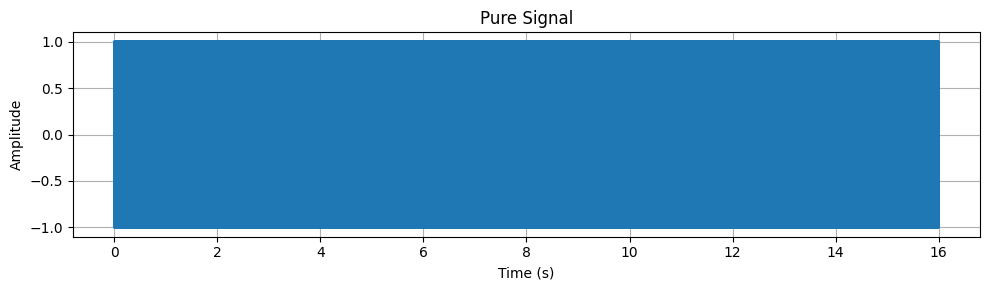

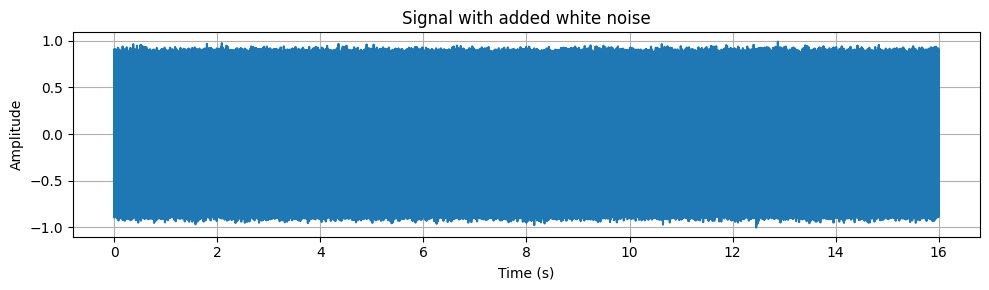

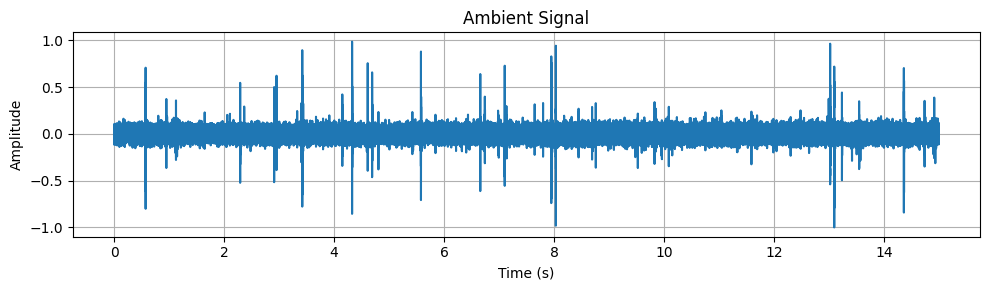

In [2]:
# Adicionando ruído branco ao sinal puro

# Carregando o sinal quase puro
fs, pureSignal = loadAudio('audio/PureSignal.wav')

# Gerando ruído branco (com a mesma duração do sinal)
np.random.seed(0) # Para reprodutibilidade
whiteNoise = np.random.normal(0, 0.05, len(pureSignal))

# Sinal com ruído adicionado
noisySignal = pureSignal + whiteNoise

# Normalizando o sinal final entre -1 e 1 (evitar clipping)
noisySignal = noisySignal / np.max(np.abs(noisySignal))

# Plotando os sinais
plotTime(pureSignal, fs, title="Pure Signal")
plotTime(noisySignal, fs, title="Signal with added white noise")

# Carregando e plotando o sinal ambiente
fs, ambientSignal = loadAudio('audio/ambientSignal.wav')
plotTime(ambientSignal, fs, title="Ambient Signal")


In [3]:
# Salvar sinal com ruído
# Convertendo para int16 antes de salvar
noisySignalInt = np.int16(noisySignal * 32767)
write('audio/NoisySignal.wav', fs, noisySignalInt)

In [4]:
# Função para calcular e plotar FFT
def plotFFT(data, fs, title="Frequency spectrum"):
    N = len(data)
    spectrum = np.abs(np.fft.fft(data))
    frequencies = np.fft.fftfreq(N, d=1/fs)

    # Só usamos a metade positiva do espectro (até Nyquist)
    idx = np.where(frequencies >= 0)
    plt.figure(figsize=(10, 3))
    plt.plot(frequencies[idx], spectrum[idx])
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

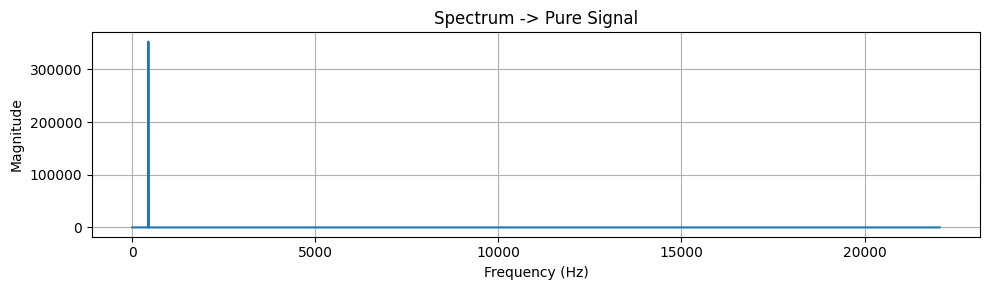

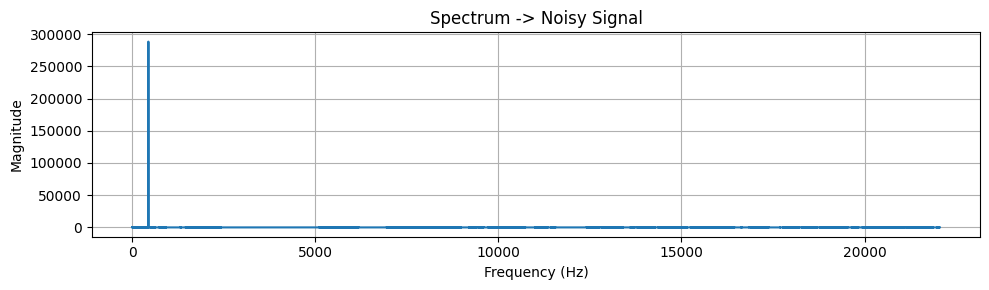

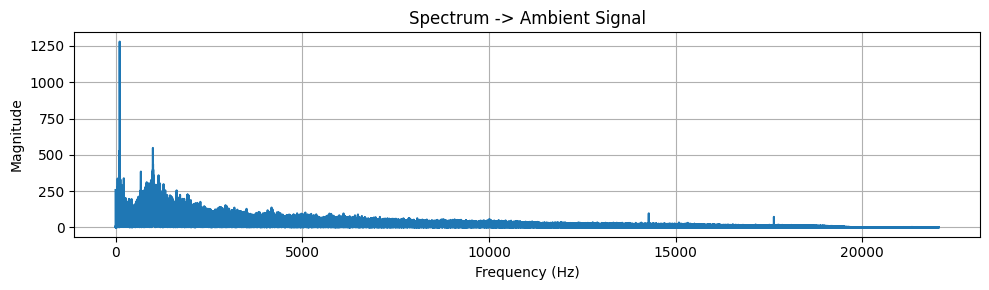

In [5]:
# Análise espectral dos 3 sinais

# FFT do sinal puro
plotFFT(pureSignal, fs, title="Spectrum -> Pure Signal")

# FFT do sinal com ruído
plotFFT(noisySignal, fs, title="Spectrum -> Noisy Signal")

# FFT do sinal ambiente
plotFFT(ambientSignal, fs, title="Spectrum -> Ambient Signal")

In [6]:
# Função para criar e aplicar o filtro passa-baixa
def lowPassFilter(data, cutoff, fs, order=6):
    nyq = 0.5 * fs # Frequência de Nyquist
    normalCutoff = cutoff / nyq
    b, a = butter(order, normalCutoff, btype='low', analog=False)
    filteredDate = lfilter(b, a, data)
    return filteredDate

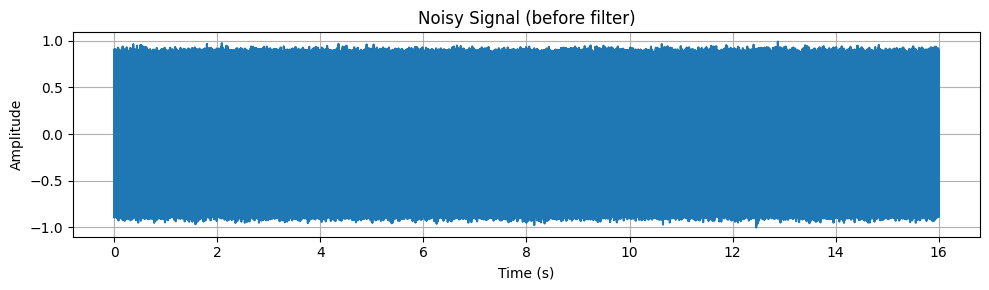

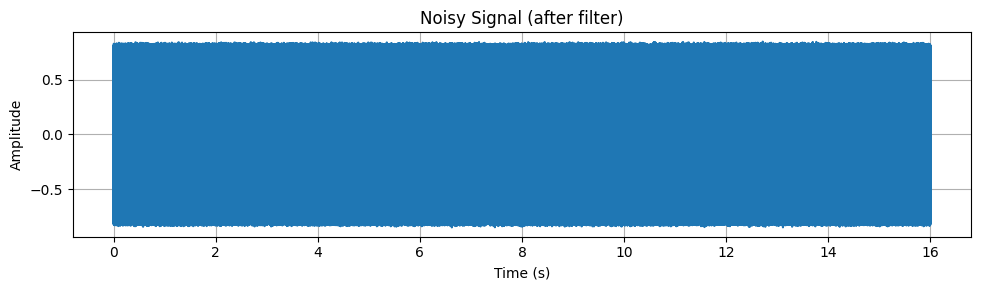

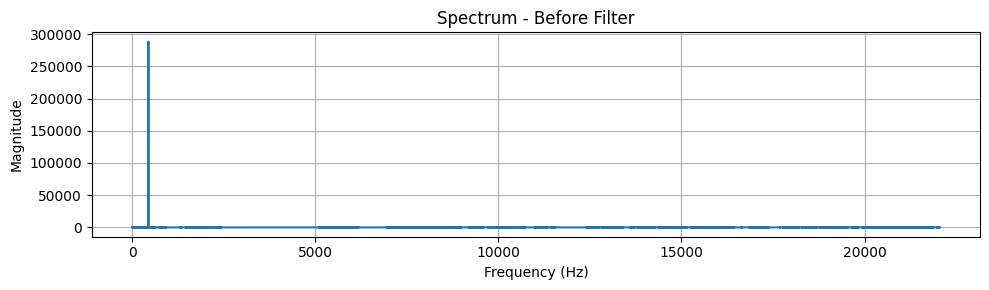

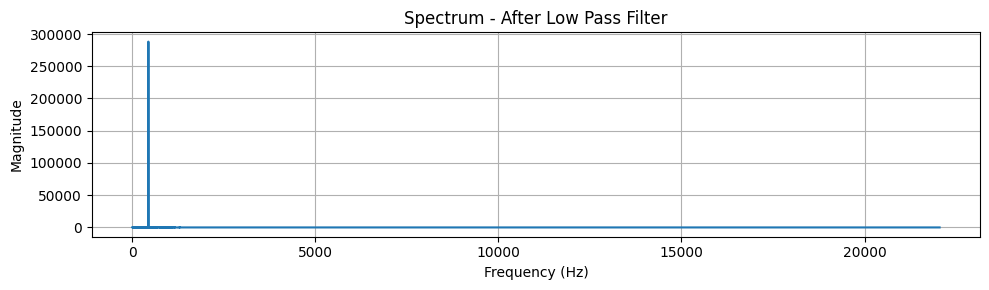

In [7]:
# Aplicar filtro ao sinal com ruído
cutoffFreq = 1000 # Hz - corte em 1000 Hz 

# Aplicando o filtro
filteredSignal = lowPassFilter(noisySignal, cutoff=cutoffFreq, fs=fs)

# Plotando os sinais
plotTime(noisySignal, fs, title="Noisy Signal (before filter)")
plotTime(filteredSignal, fs, title="Noisy Signal (after filter)")

# FFT comparativa
plotFFT(noisySignal, fs, title="Spectrum - Before Filter")
plotFFT(filteredSignal, fs, title="Spectrum - After Low Pass Filter")

In [8]:
# Cálculo do SNR

# Função para calcular a razão sinal-ruído (em dB)
def calculateSNR(originalSign, disturbedSignal):
    noise = disturbedSignal - originalSign
    signalPower = np.mean(originalSign**2)
    noisePower = np.mean(noise**2)
    if noisePower == 0:
        return np.inf # SNR infinito, sem ruído
    snr = 10 * np.log10(signalPower / noisePower)
    return snr

In [9]:
# Comparando o SNR

snrBefore = calculateSNR(pureSignal, noisySignal)
snrAfter = calculateSNR(pureSignal, filteredSignal)

print(f"SNR before filter: {snrBefore:.2f} dB")
print(f"SNR after filter: {snrAfter:.2f} dB")

SNR before filter: 14.34 dB
SNR after filter: -2.89 dB


In [10]:
# Filtro passa-baixa com filtfilt

# Novo filtro com filtfilt (zero-phase)
def lowPassFilterZeroPhase(data, cutoff, fs, order=6):
    nyq = 0.5 * fs
    normalCutoff = cutoff / nyq
    b, a = butter(order, normalCutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

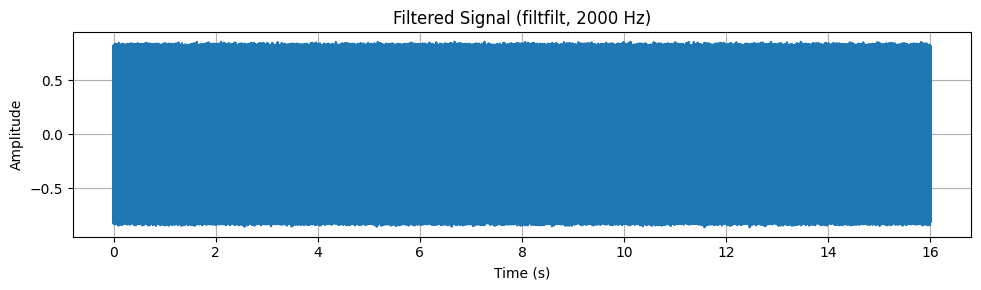

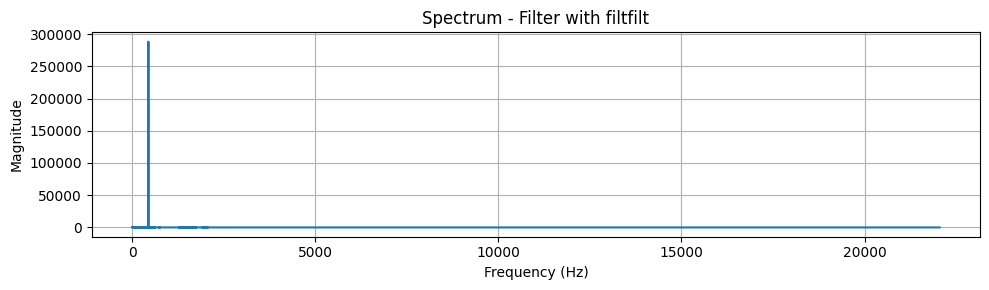

SNR after filter with filtfilt: 14.71 dB


In [11]:
# Aplicart o novo filtro e comparar
newCutoff = 2000 # Hz

# Aplicar filtro com filtfilt
filteredSignal2 = lowPassFilterZeroPhase(noisySignal, newCutoff, fs)

# Visualizar no tempo e espectro
plotTime(filteredSignal2, fs, title="Filtered Signal (filtfilt, 2000 Hz)")
plotFFT(filteredSignal2, fs, title="Spectrum - Filter with filtfilt")

# Comparar novamente o SNR
snrAfterFiltfilt = calculateSNR(pureSignal, filteredSignal2)
print(f"SNR after filter with filtfilt: {snrAfterFiltfilt:.2f} dB")



## Análise dos Componentes Espectrais

### Sinal Puro
O espectro do sinal puro apresenta um único pico dominante próximo a 440 Hz, correspondente à frequência fundamental do tom senoidal utilizado. Não há presença significativa de outras frequências, indicando a pureza do sinal.

### Sinal com Ruído
Neste caso, o espectro mantém o pico em 440 Hz, mas apresenta uma base espalhada de energia em várias frequências — evidência clara da adição de ruído branco, que se distribui uniformemente no espectro. A relação sinal-ruído (SNR) inicial foi de **14.34 dB**, o que indica que o sinal útil ainda era perceptível, mas já contaminado.

### Sinal Ambiente
O espectro do som ambiente apresenta uma distribuição ampla e contínua de energia em várias faixas de frequência, com alguns picos e variações. Esse comportamento é típico de ambientes reais com múltiplas fontes sonoras (tráfego, vozes, vento, etc.), sem periodicidade definida.



## Discussão dos Resultados

A análise espectral revelou claramente as características distintas de cada tipo de sinal. O sinal puro apresentou um espectro limpo e definido, enquanto a adição de ruído branco espalhou energia em múltiplas frequências. O sinal ambiente, por sua vez, apresentou uma distribuição rica e variada, representando bem a complexidade sonora do mundo real.

Na tentativa de recuperar o sinal puro a partir do sinal ruidoso, foram aplicados filtros passa-baixa. O primeiro teste, utilizando `lfilter` com frequência de corte de 1000 Hz, resultou em uma degradação severa do sinal útil, com um SNR de **-2.89 dB** — indicando que o ruído superou o sinal.

Posteriormente, aplicamos um filtro com `filtfilt`, que evita distorção de fase, e ajustamos a frequência de corte para 2000 Hz. Esse ajuste melhorou significativamente o desempenho, atingindo um SNR de **14.71 dB**, superior ao valor original, o que mostra a eficácia da filtragem quando corretamente configurada.



## Conclusão

Este trabalho demonstrou, na prática, como a análise espectral por meio da Transformada de Fourier é uma ferramenta poderosa para compreender e caracterizar sinais de áudio. Foi possível identificar visualmente e numericamente a presença de ruído em um sinal contaminado, e aplicar técnicas de filtragem para tentar recuperar sua forma original.

O uso de filtros passa-baixa mostrou que, quando mal configurados, podem distorcer o sinal desejado. Porém, com escolha adequada da frequência de corte e técnica de filtragem (como `filtfilt`), é possível melhorar substancialmente a qualidade do sinal, como comprovado pelos resultados de SNR.

A abordagem proposta é essencial em aplicações como processamento de voz, telecomunicações, áudio digital e engenharia biomédica, onde a integridade do sinal é crítica.
